In [1]:
import os
import sys

import pickle
import numpy as np
import pandas as pd

In [2]:
#se the working directory
os.chdir('/pdo/users/pablomer/Astronet-Triage')

In [3]:
# Later, load the list from the file
with open('astronet/training/data.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

# Verify the data
print(loaded_data)

[(      astro_id    disp_p    disp_e    disp_n    disp_j
0            1  0.004610  0.993987  0.000674  0.000730
1            2  0.006256  0.991784  0.000858  0.001102
2            3  0.000819  0.996856  0.000536  0.001789
3            4  0.031421  0.966963  0.001027  0.000588
4            5  0.000269  0.999471  0.000104  0.000156
...        ...       ...       ...       ...       ...
1872      1879  0.000031  0.999925  0.000009  0.000035
1873      1880  0.000083  0.999760  0.000036  0.000121
1874      1881  0.013248  0.981024  0.001830  0.003897
1875      1882  0.715246  0.273600  0.006778  0.004376
1876      1883  0.039968  0.902437  0.006803  0.050792

[1877 rows x 5 columns], {'inputs': {'label_columns': ['disp_p', 'disp_e', 'disp_n', 'disp_j'], 'exclusive_labels': True, 'features': {'local_aperture_s': {'shape': [61], 'is_time_series': True, 'vetting_only': True}, 'local_aperture_m': {'shape': [61], 'is_time_series': True, 'vetting_only': True}, 'local_aperture_l': {'shape': [61], 

In [4]:
# Cell 4: Aggregate predictions across folds
import pandas as pd
all_predictions=loaded_data

# Extract prediction DataFrames from tuples (ignoring config)
prediction_dfs = [pred for pred, _ in all_predictions]

# Concatenate predictions from all folds into a single DataFrame
combined_predictions = pd.concat(prediction_dfs, ignore_index=True)

#Make astro_id the index
combined_predictions.set_index('astro_id', inplace=True)

# Display aggregated predictions
print(combined_predictions.head())


            disp_p    disp_e    disp_n    disp_j
astro_id                                        
1         0.004610  0.993987  0.000674  0.000730
2         0.006256  0.991784  0.000858  0.001102
3         0.000819  0.996856  0.000536  0.001789
4         0.031421  0.966963  0.001027  0.000588
5         0.000269  0.999471  0.000104  0.000156


In [5]:
# Cell 5: Compute global performance metrics
# Load ground truth labels
# tc = pd.read_csv(TCES_FILE)
TCES_FILE = "../mnt/tess/astronet/tces-vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle-all.csv"
tce_table = pd.read_csv(TCES_FILE, header=0, low_memory=False)
tce_table['astro_id'] = tce_table['Astro ID']
tce_table = tce_table.set_index('astro_id')


labels = ['disp_p', 'disp_e', 'disp_n', 'disp_j']
for l in labels:
    tce_table[l] = tce_table[l[:-1] + l[-1]]
# keep only the columns with the labels and the TIC ID

thresh = 0.215

tce_labels = tce_table[labels + ['TIC ID']]

print(tce_labels.head(25))

          disp_p  disp_e  disp_n  disp_j     TIC ID
astro_id                                           
1              0       1       0       0  101179364
2              0       1       0       0  101255974
3              0       1       0       0  101404344
4              0       1       0       0  101427335
5              0       1       0       0   10150705
6              0       1       0       0  101513965
7              0       1       0       0  101546875
8              0       1       0       0  101547609
9              0       1       0       0  101675455
10             0       1       0       0  101695924
11             0       1       0       0  102731164
12             0       1       0       0  103573024
13             0       1       0       0  103657171
14             0       1       0       0  104914008
15             0       1       0       0  105618511
16             1       0       0       0  106013773
17             0       1       0       0   10697190
18          

In [6]:
# Specify the columns that represent votes/labels
label_cols = ['disp_p','disp_e','disp_n','disp_j']

# Keep track of rows where ties occur
tie_rows = []

def ensure_single_label(row):
    # Extract values for the label columns
    vals = row[label_cols].values

    # Find the maximum vote in this row
    max_val = vals.max()

    # Find which columns have the max vote
    tied_idx = np.where(vals == max_val)[0]  # array of indices that share the max

    if len(tied_idx) > 1:
        # We have a tie—choose one at random
        chosen_idx = np.random.choice(tied_idx)
        tie_rows.append(row.name)
    else:
        chosen_idx = tied_idx[0]

    # Zero out all labels, then set the chosen one to 1
    row[label_cols] = 0
    row[label_cols[chosen_idx]] = 1

    return row

df = tce_labels.apply(ensure_single_label, axis=1)

print("DataFrame after enforcing single label per row:")
print(df)
print("\nRows that had ties (randomly broken):", tie_rows)

DataFrame after enforcing single label per row:
          disp_p  disp_e  disp_n  disp_j     TIC ID
astro_id                                           
1              0       1       0       0  101179364
2              0       1       0       0  101255974
3              0       1       0       0  101404344
4              0       1       0       0  101427335
5              0       1       0       0   10150705
...          ...     ...     ...     ...        ...
28608          0       0       0       1   55369279
28622          0       0       0       1    5647469
28629          0       0       0       1    5784648
28738          0       0       0       1     712837
28878          0       0       0       1    9257397

[9389 rows x 5 columns]

Rows that had ties (randomly broken): [440, 1095, 1242, 1944, 2158, 3854, 3943, 3944, 3959, 3964, 3972, 3977, 3978, 3995]


In [7]:
df['disp_p']

astro_id
1        0
2        0
3        0
4        0
5        0
        ..
28608    0
28622    0
28629    0
28738    0
28878    0
Name: disp_p, Length: 9389, dtype: int64

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 

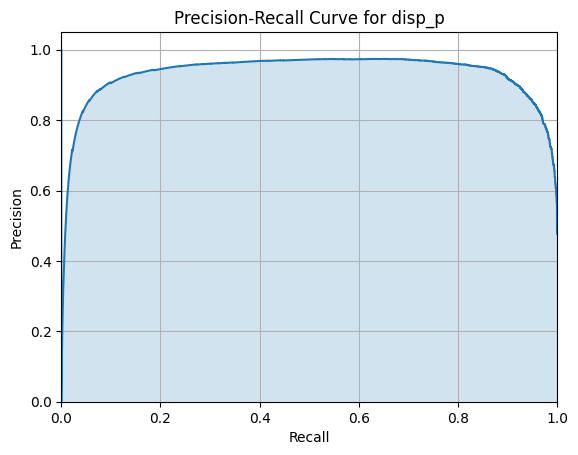

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 

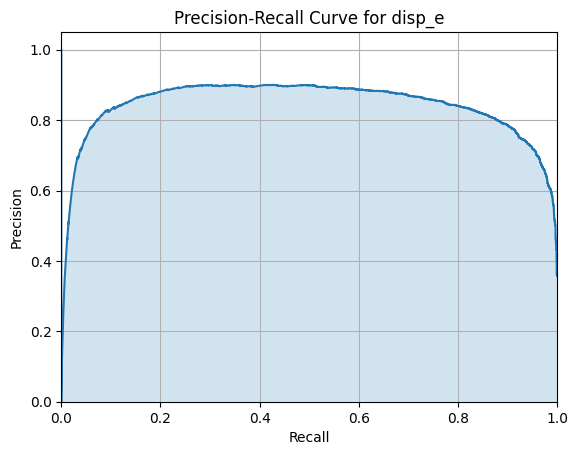

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

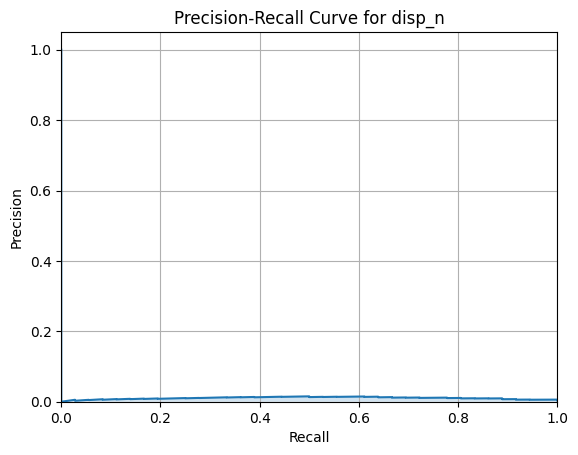

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

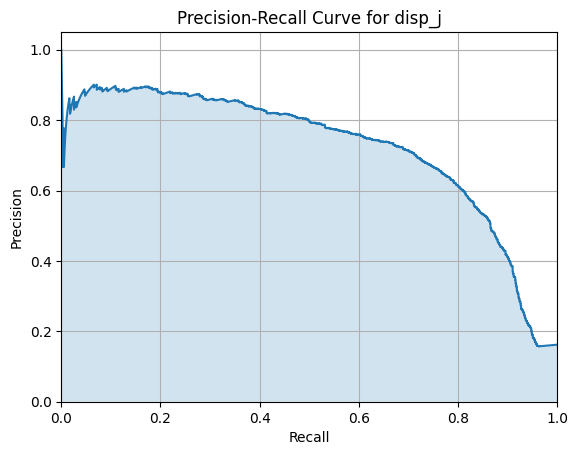

In [8]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt


for label in labels:
    #initialize y_true and y_scores as empty lists
    y_true = []
    y_scores = []


    for astro_id in combined_predictions.index:
        # Check if astro_id exists in df
        if astro_id in df.index:
            # Append the corresponding value to y_true
            y_true.append(df.at[astro_id, label])
            # Append the corresponding prediction to y_scores
            y_scores.append(combined_predictions.at[astro_id, label])
        else:
            print(f"astro_id {astro_id} not found in df")

    print(y_true)
    print(y_scores)
    # Calculate precision and recall
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

    # Plot the precision-recall curve
    plt.figure()
    plt.plot(recall, precision)
    plt.title(f'Precision-Recall Curve for {label}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.grid(True)
    plt.fill_between(recall, precision, alpha=0.2)
    plt.show()


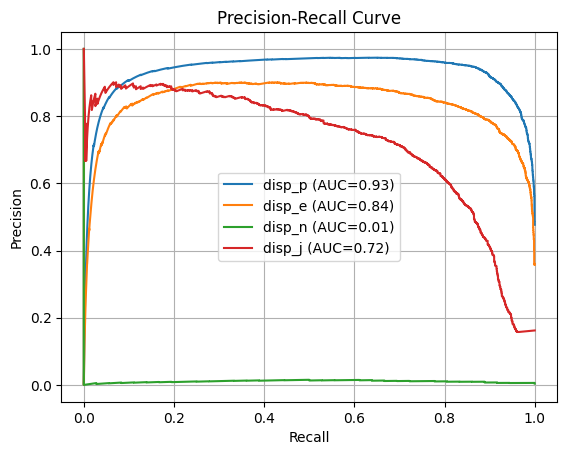

In [12]:
from sklearn.metrics import precision_recall_curve, roc_curve, confusion_matrix, auc, ConfusionMatrixDisplay


# PR Curve
plt.figure()
for label in labels:
    y_true = []
    y_scores = []

    for astro_id in combined_predictions.index:
        if astro_id in df.index:
            y_true.append(df.at[astro_id, label])
            y_scores.append(combined_predictions.at[astro_id, label])
        else:
            print(f"astro_id {astro_id} not found in df")
    
    # Convert to numpy arrays
    y_true = np.array(y_true).astype(int)
    y_scores = np.array(y_scores)

    # Calculate precision and recall
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    auc_val = auc(recall, precision)

    plt.plot(recall, precision, label=f"{label} (AUC={auc_val:.2f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()



### Testing with the ensemble model to see what happens

In [9]:
import zipfile
import pandas as pd

zip_path = "ensemble_preds.zip"  # path to your zip file

dfs_list = []  # list to hold all DataFrames

with zipfile.ZipFile(zip_path, 'r') as z:
    # List all files in the zip
    for file_name in z.namelist():
        # Check if it is a CSV
        if file_name.endswith(".csv"):
            # Read the CSV as a DataFrame
            with z.open(file_name) as f:
                df_model = pd.read_csv(f)
                dfs_list.append((file_name, df_model))

# Now 'dfs' is a list of tuples: (filename, DataFrame)
for name, df_model in dfs_list:
    print(f"\nLoaded {name}, shape={df_model.shape}")



Loaded model_5.csv, shape=(1073, 5)

Loaded model_2.csv, shape=(1073, 5)

Loaded model_3.csv, shape=(1073, 5)

Loaded model_4.csv, shape=(1073, 5)

Loaded model_9.csv, shape=(1073, 5)

Loaded model_7.csv, shape=(1073, 5)

Loaded model_0.csv, shape=(1073, 5)

Loaded model_1.csv, shape=(1073, 5)

Loaded model_6.csv, shape=(1073, 5)

Loaded model_8.csv, shape=(1073, 5)


In [10]:
predictions_1=dfs_list[0][1]
#set astro_id as the index
predictions_1.set_index('astro_id', inplace=True)
predictions_1.head(25)

,disp_p,disp_e,disp_n,disp_j
astro_id,,,,
5916,0.999563,0.000301,0.000065,0.000072
10164,0.988356,0.001335,0.000877,0.009432
10772,0.999034,0.000189,0.000048,0.000729
1105,0.038490,0.954991,0.003524,0.002996
2415,0.024704,0.961613,0.006575,0.007108
2038,0.034091,0.960221,0.003084,0.002604
6215,0.994150,0.002336,0.001020,0.002495
8612,0.999414,0.000551,0.000025,0.000010
10520,0.996726,0.000141,0.000114,0.003019


astro_id 10164 not found in df
astro_id 10772 not found in df
astro_id 10520 not found in df
astro_id 9428 not found in df
astro_id 9393 not found in df
astro_id 10530 not found in df
astro_id 10267 not found in df
astro_id 10905 not found in df
astro_id 10682 not found in df
astro_id 10584 not found in df
astro_id 9896 not found in df
astro_id 10359 not found in df
astro_id 9698 not found in df
astro_id 10304 not found in df
astro_id 10384 not found in df
astro_id 10649 not found in df
astro_id 10761 not found in df
astro_id 10841 not found in df
astro_id 10116 not found in df
astro_id 9474 not found in df
astro_id 10966 not found in df
astro_id 10189 not found in df
astro_id 9957 not found in df
astro_id 9873 not found in df
astro_id 10362 not found in df
astro_id 10515 not found in df
astro_id 10948 not found in df
astro_id 10236 not found in df
astro_id 10751 not found in df
astro_id 10415 not found in df
astro_id 9656 not found in df
astro_id 10377 not found in df
astro_id 9771 no

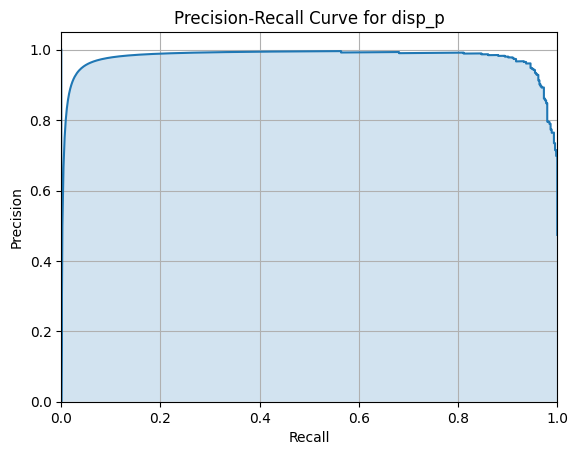

astro_id 10164 not found in df
astro_id 10772 not found in df
astro_id 10520 not found in df
astro_id 9428 not found in df
astro_id 9393 not found in df
astro_id 10530 not found in df
astro_id 10267 not found in df
astro_id 10905 not found in df
astro_id 10682 not found in df
astro_id 10584 not found in df
astro_id 9896 not found in df
astro_id 10359 not found in df
astro_id 9698 not found in df
astro_id 10304 not found in df
astro_id 10384 not found in df
astro_id 10649 not found in df
astro_id 10761 not found in df
astro_id 10841 not found in df
astro_id 10116 not found in df
astro_id 9474 not found in df
astro_id 10966 not found in df
astro_id 10189 not found in df
astro_id 9957 not found in df
astro_id 9873 not found in df
astro_id 10362 not found in df
astro_id 10515 not found in df
astro_id 10948 not found in df
astro_id 10236 not found in df
astro_id 10751 not found in df
astro_id 10415 not found in df
astro_id 9656 not found in df
astro_id 10377 not found in df
astro_id 9771 no

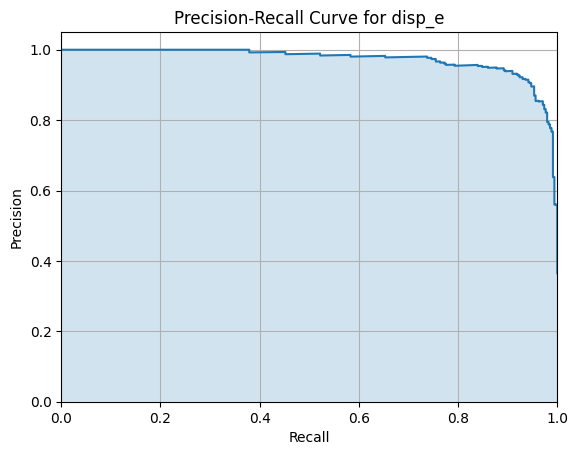

astro_id 10164 not found in df
astro_id 10772 not found in df
astro_id 10520 not found in df
astro_id 9428 not found in df
astro_id 9393 not found in df
astro_id 10530 not found in df
astro_id 10267 not found in df
astro_id 10905 not found in df
astro_id 10682 not found in df
astro_id 10584 not found in df
astro_id 9896 not found in df
astro_id 10359 not found in df
astro_id 9698 not found in df
astro_id 10304 not found in df
astro_id 10384 not found in df
astro_id 10649 not found in df
astro_id 10761 not found in df
astro_id 10841 not found in df
astro_id 10116 not found in df
astro_id 9474 not found in df
astro_id 10966 not found in df
astro_id 10189 not found in df
astro_id 9957 not found in df
astro_id 9873 not found in df
astro_id 10362 not found in df
astro_id 10515 not found in df
astro_id 10948 not found in df
astro_id 10236 not found in df
astro_id 10751 not found in df
astro_id 10415 not found in df
astro_id 9656 not found in df
astro_id 10377 not found in df
astro_id 9771 no

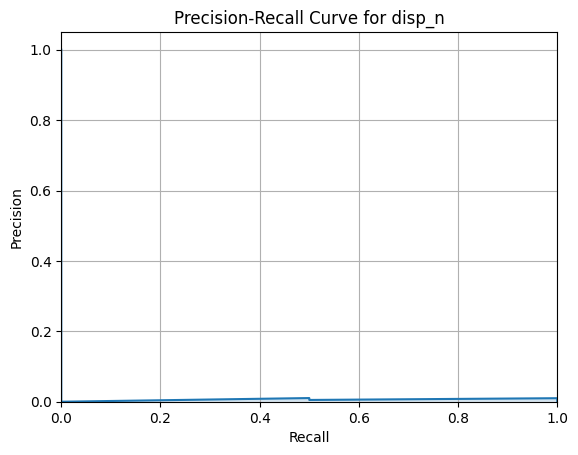

astro_id 10164 not found in df
astro_id 10772 not found in df
astro_id 10520 not found in df
astro_id 9428 not found in df
astro_id 9393 not found in df
astro_id 10530 not found in df
astro_id 10267 not found in df
astro_id 10905 not found in df
astro_id 10682 not found in df
astro_id 10584 not found in df
astro_id 9896 not found in df
astro_id 10359 not found in df
astro_id 9698 not found in df
astro_id 10304 not found in df
astro_id 10384 not found in df
astro_id 10649 not found in df
astro_id 10761 not found in df
astro_id 10841 not found in df
astro_id 10116 not found in df
astro_id 9474 not found in df
astro_id 10966 not found in df
astro_id 10189 not found in df
astro_id 9957 not found in df
astro_id 9873 not found in df
astro_id 10362 not found in df
astro_id 10515 not found in df
astro_id 10948 not found in df
astro_id 10236 not found in df
astro_id 10751 not found in df
astro_id 10415 not found in df
astro_id 9656 not found in df
astro_id 10377 not found in df
astro_id 9771 no

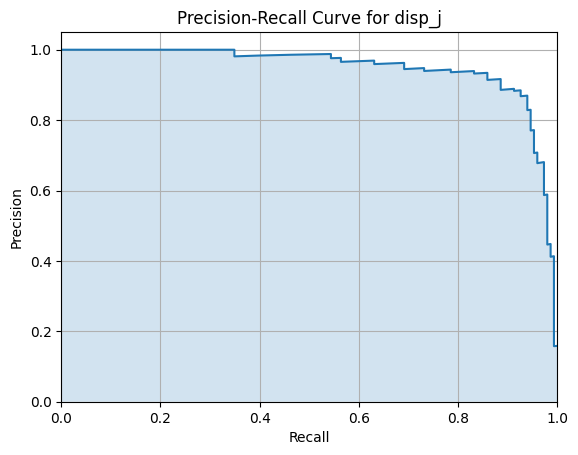

In [11]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt


for label in labels:
    #initialize y_true and y_scores as empty lists
    y_true = []
    y_scores = []


    for astro_id in predictions_1.index:
        # Check if astro_id exists in df
        if astro_id in df.index:
            # Append the corresponding value to y_true
            y_true.append(df.at[astro_id, label])
            # Append the corresponding prediction to y_scores
            y_scores.append(predictions_1.at[astro_id, label])
        else:
            print(f"astro_id {astro_id} not found in df")

    print(y_true)
    print(y_scores)
    # Calculate precision and recall
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

    # Plot the precision-recall curve
    plt.figure()
    plt.plot(recall, precision)
    plt.title(f'Precision-Recall Curve for {label}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.grid(True)
    plt.fill_between(recall, precision, alpha=0.2)
    plt.show()
